# Transfer Learning using PyTorch

In [ ]:
!nvidia-smi

Thu Feb 19 05:55:14 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   52C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## Load Important Libraries

In [ ]:
# License: BSD
# Author: Sasank Chilamkurthy

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
import torch.backends.cudnn as cudnn
import numpy as np
import torchvision
from torchvision import datasets, models, transforms
import matplotlib.pyplot as plt
import time
import os
from PIL import Image
from tempfile import TemporaryDirectory

cudnn.benchmark = True
plt.ion()   # interactive mode

## Load Data
=========

We will use torchvision and torch.utils.data packages for loading the
data.

The problem we\'re going to solve today is to train a model to classify
**ants** and **bees**. We have about 120 training images each for ants
and bees. There are 75 validation images for each class. Usually, this
is a very small dataset to generalize upon, if trained from scratch.
Since we are using transfer learning, we should be able to generalize
reasonably well.

This dataset is a very small subset of imagenet.


In [ ]:
!rm -R /content/hymenoptera_data/train/.ipynb_checkpoints
!ls /content/hymenoptera_data/test/train -a   #to make sure that the deletion has occurred

!rm -R /content/hymenoptera_data/val/.ipynb_checkpoints
!ls /content/hymenoptera_data/val -a   #to make sure that the deletion has occurred

rm: cannot remove '/content/hymenoptera_data/train/.ipynb_checkpoints': No such file or directory
ls: cannot access '/content/hymenoptera_data/test/train': No such file or directory
rm: cannot remove '/content/hymenoptera_data/val/.ipynb_checkpoints': No such file or directory
ls: cannot access '/content/hymenoptera_data/val': No such file or directory


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Data augmentation and normalization for training
# Just normalization for validation
data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

data_dir = '/content/drive/MyDrive/hymenoptera_data/hymenoptera_data'
image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x),
                                          data_transforms[x])
                  for x in ['train', 'val']}
dataloaders = {x: torch.utils.data.DataLoader(image_datasets[x], batch_size=4,
                                             shuffle=True, num_workers=4)
              for x in ['train', 'val']}
dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val']}
class_names = image_datasets['train'].classes

# We want to be able to train our model on an `accelerator <https://pytorch.org/docs/stable/torch.html#accelerators>`__
# such as CUDA, MPS, MTIA, or XPU. If the current accelerator is available, we will use it. Otherwise, we use the CPU.

device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

Using cuda device


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


## Visualize a few images
======================

Let\'s visualize a few training images so as to understand the data
augmentations.


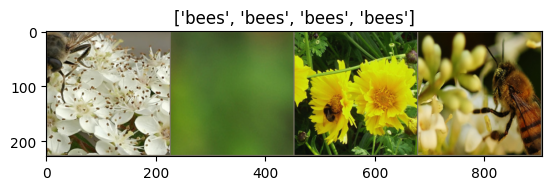

In [ ]:
def imshow(inp, title=None):
    """Display image for Tensor."""
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.pause(0.001)  # pause a bit so that plots are updated


# Get a batch of training data
inputs, classes = next(iter(dataloaders['train']))

# Make a grid from batch
out = torchvision.utils.make_grid(inputs)

imshow(out, title=[class_names[x] for x in classes])

## Training the model
==================

Now, let\'s write a general function to train a model. Here, we will
illustrate:

-   Scheduling the learning rate
-   Saving the best model

In the following, parameter `scheduler` is an LR scheduler object from
`torch.optim.lr_scheduler`.


In [ ]:
def train_model(model, criterion, optimizer, scheduler, num_epochs=25):
    since = time.time()

    # Create a temporary directory to save training checkpoints
    with TemporaryDirectory() as tempdir:
        best_model_params_path = os.path.join(tempdir, 'best_model_params.pt')

        torch.save(model.state_dict(), best_model_params_path)
        best_acc = 0.0

        for epoch in range(num_epochs):
            print(f'Epoch {epoch}/{num_epochs - 1}')
            print('-' * 10)

            # Each epoch has a training and validation phase
            for phase in ['train', 'val']:
                if phase == 'train':
                    model.train()  # Set model to training mode
                else:
                    model.eval()   # Set model to evaluate mode

                running_loss = 0.0
                running_corrects = 0

                # Iterate over data.
                for inputs, labels in dataloaders[phase]:
                    inputs = inputs.to(device)
                    labels = labels.to(device)

                    # zero the parameter gradients
                    optimizer.zero_grad()

                    # forward
                    # track history if only in train
                    with torch.set_grad_enabled(phase == 'train'):
                        outputs = model(inputs)
                        _, preds = torch.max(outputs, 1)
                        loss = criterion(outputs, labels)

                        # backward + optimize only if in training phase
                        if phase == 'train':
                            loss.backward()
                            optimizer.step()

                    # statistics
                    running_loss += loss.item() * inputs.size(0)
                    running_corrects += torch.sum(preds == labels.data)
                if phase == 'train':
                    scheduler.step()

                epoch_loss = running_loss / dataset_sizes[phase]
                epoch_acc = running_corrects.double() / dataset_sizes[phase]

                print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

                # deep copy the model
                if phase == 'val' and epoch_acc > best_acc:
                    best_acc = epoch_acc
                    torch.save(model.state_dict(), best_model_params_path)

            print()

        time_elapsed = time.time() - since
        print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
        print(f'Best val Acc: {best_acc:4f}')

        # load best model weights
        model.load_state_dict(torch.load(best_model_params_path, weights_only=True))
    return model

## Visualizing the model predictions
=================================

Generic function to display predictions for a few images


In [ ]:
def visualize_model(model, num_images=6):
    was_training = model.training
    model.eval()
    images_so_far = 0
    fig = plt.figure()

    with torch.no_grad():
        for i, (inputs, labels) in enumerate(dataloaders['val']):
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            for j in range(inputs.size()[0]):
                images_so_far += 1
                ax = plt.subplot(num_images//2, 2, images_so_far)
                ax.axis('off')
                ax.set_title(f'predicted: {class_names[preds[j]]}')
                imshow(inputs.cpu().data[j])

                if images_so_far == num_images:
                    model.train(mode=was_training)
                    return
        model.train(mode=was_training)

## Finetuning the ConvNet
======================

Load a pretrained model and reset final fully connected layer.


In [ ]:
model_ft = models.resnet18(weights='IMAGENET1K_V1')
num_ftrs = model_ft.fc.in_features
# Here the size of each output sample is set to 2.
# Alternatively, it can be generalized to ``nn.Linear(num_ftrs, len(class_names))``.
model_ft.fc = nn.Linear(num_ftrs, 2)

model_ft = model_ft.to(device)

criterion = nn.CrossEntropyLoss()

# Observe that all parameters are being optimized
optimizer_ft = optim.SGD(model_ft.parameters(), lr=0.001, momentum=0.9)

# Decay LR by a factor of 0.1 every 7 epochs
exp_lr_scheduler = lr_scheduler.StepLR(optimizer_ft, step_size=7, gamma=0.1)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 131MB/s]


## Train and evaluate
==================

It should take around 15-25 min on CPU. On GPU though, it takes less
than a minute.


In [ ]:
model_ft = train_model(model_ft, criterion, optimizer_ft, exp_lr_scheduler,
                       num_epochs=25)

Epoch 0/24
----------


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


train Loss: 0.5552 Acc: 0.7008
val Loss: 0.2506 Acc: 0.9150

Epoch 1/24
----------
train Loss: 0.5846 Acc: 0.7746
val Loss: 0.2196 Acc: 0.9346

Epoch 2/24
----------
train Loss: 0.7204 Acc: 0.7582
val Loss: 0.3611 Acc: 0.8693

Epoch 3/24
----------
train Loss: 0.5687 Acc: 0.7418
val Loss: 0.5556 Acc: 0.8627

Epoch 4/24
----------
train Loss: 0.6408 Acc: 0.7705
val Loss: 0.2909 Acc: 0.8824

Epoch 5/24
----------
train Loss: 0.7909 Acc: 0.7172
val Loss: 1.0894 Acc: 0.7386

Epoch 6/24
----------
train Loss: 0.7743 Acc: 0.7705
val Loss: 0.5737 Acc: 0.8235

Epoch 7/24
----------
train Loss: 0.4604 Acc: 0.8279
val Loss: 0.3384 Acc: 0.8889

Epoch 8/24
----------
train Loss: 0.3563 Acc: 0.8852
val Loss: 0.3221 Acc: 0.8954

Epoch 9/24
----------
train Loss: 0.2254 Acc: 0.9139
val Loss: 0.2971 Acc: 0.9085

Epoch 10/24
----------
train Loss: 0.4249 Acc: 0.8074
val Loss: 0.2826 Acc: 0.9216

Epoch 11/24
----------
train Loss: 0.3192 Acc: 0.8648
val Loss: 0.2611 Acc: 0.9346

Epoch 12/24
----------
t

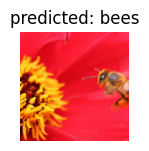

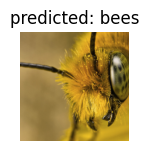

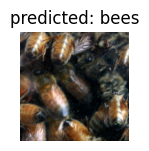

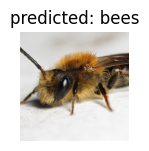

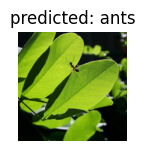

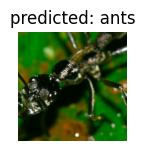

In [ ]:
visualize_model(model_ft)

## ConvNet as fixed feature extractor
==================================

Here, we need to freeze all the network except the final layer. We need
to set `requires_grad = False` to freeze the parameters so that the
gradients are not computed in `backward()`.

You can read more about this in the documentation
[here](https://pytorch.org/docs/notes/autograd.html#excluding-subgraphs-from-backward).


In [ ]:
model_conv = torchvision.models.resnet18(weights='IMAGENET1K_V1')
for param in model_conv.parameters():
    param.requires_grad = False

# Parameters of newly constructed modules have requires_grad=True by default
num_ftrs = model_conv.fc.in_features
model_conv.fc = nn.Linear(num_ftrs, 2)

model_conv = model_conv.to(device)

criterion = nn.CrossEntropyLoss()

# Observe that only parameters of final layer are being optimized as
# opposed to before.
optimizer_conv = optim.SGD(model_conv.fc.parameters(), lr=0.001, momentum=0.9)

# Decay LR by a factor of 0.1 every 7 epochs
exp_lr_scheduler = lr_scheduler.StepLR(optimizer_conv, step_size=7, gamma=0.1)

## Train and evaluate
==================

On CPU this will take about half the time compared to previous scenario.
This is expected as gradients don\'t need to be computed for most of the
network. However, forward does need to be computed.


In [ ]:
model_conv = train_model(model_conv, criterion, optimizer_conv,
                         exp_lr_scheduler, num_epochs=25)

Epoch 0/24
----------
train Loss: 0.6472 Acc: 0.6516
val Loss: 0.2073 Acc: 0.9281

Epoch 1/24
----------
train Loss: 0.4513 Acc: 0.7951
val Loss: 0.2211 Acc: 0.9020

Epoch 2/24
----------
train Loss: 0.5210 Acc: 0.7623
val Loss: 0.1734 Acc: 0.9477

Epoch 3/24
----------
train Loss: 0.4086 Acc: 0.8197
val Loss: 0.1389 Acc: 0.9608

Epoch 4/24
----------
train Loss: 0.4961 Acc: 0.7705
val Loss: 0.2343 Acc: 0.8954

Epoch 5/24
----------
train Loss: 0.4188 Acc: 0.8156
val Loss: 0.2106 Acc: 0.9346

Epoch 6/24
----------
train Loss: 0.4358 Acc: 0.8320
val Loss: 0.2619 Acc: 0.9085

Epoch 7/24
----------
train Loss: 0.5073 Acc: 0.7869
val Loss: 0.1957 Acc: 0.9412

Epoch 8/24
----------
train Loss: 0.3194 Acc: 0.8648
val Loss: 0.1540 Acc: 0.9542

Epoch 9/24
----------
train Loss: 0.2875 Acc: 0.8730
val Loss: 0.1745 Acc: 0.9477

Epoch 10/24
----------
train Loss: 0.3627 Acc: 0.8238
val Loss: 0.1679 Acc: 0.9477

Epoch 11/24
----------
train Loss: 0.2907 Acc: 0.8648
val Loss: 0.1860 Acc: 0.9281

Ep

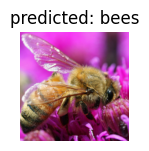

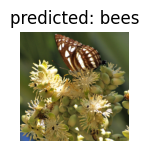

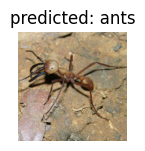

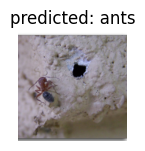

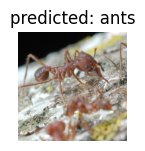

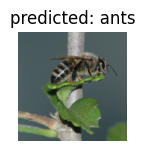

In [ ]:
visualize_model(model_conv)

plt.ioff()
plt.show()

## Inference on custom images
==========================

Use the trained model to make predictions on custom images and visualize
the predicted class labels along with the images.


In [ ]:
def visualize_model_predictions(model,img_path):
    was_training = model.training
    model.eval()

    img = Image.open(img_path)
    img = data_transforms['val'](img)
    img = img.unsqueeze(0)
    img = img.to(device)

    with torch.no_grad():
        outputs = model(img)
        _, preds = torch.max(outputs, 1)

        ax = plt.subplot(2,2,1)
        ax.axis('off')
        ax.set_title(f'Predicted: {class_names[preds[0]]}')
        imshow(img.cpu().data[0])

        model.train(mode=was_training)

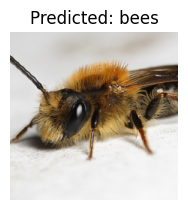

In [ ]:
visualize_model_predictions(
    model_conv,
    img_path='/content/drive/MyDrive/hymenoptera_data/val/bees/2407809945_fb525ef54d.jpg'
)

plt.ioff()
plt.show()

## Further Learning
================

If you would like to learn more about the applications of transfer
learning, checkout the
* [Quantized Transfer Learning for Computer Vision
Tutorial](https://pytorch.org/tutorials/intermediate/quantized_transfer_learning_tutorial.html).


# Supplementary Activity

In a new notebook, perform the following:
1. Choose a pretrained model.
2. Finetune on your dataset from the previous activity.
3. Evaluate the performance of the previous model to this finetuned model.

4. Utilize the pretrained ConvNet model as fixed feature extractor.
5. Evaluate the performance of the previous model to this finetuned model.

6.  Discuss the following:
  * How did finetuning affect your performance?
  * Which of the different situations for rule of thumb were applicable to you?

## Choose a pretrained model.

In [ ]:
from torchvision.models import inception_v3
supp_model = torchvision.models.inception_v3(weights='IMAGENET1K_V1')

In [ ]:
# Data for Inception V3
data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(299),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize(299),
        transforms.CenterCrop(299),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

data_dir = '/content/drive/MyDrive/hymenoptera_data/hymenoptera_data'
image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x),
                                          data_transforms[x])
                  for x in ['train', 'val']}
dataloaders = {x: torch.utils.data.DataLoader(image_datasets[x], batch_size=4,
                                             shuffle=True, num_workers=4)
              for x in ['train', 'val']}
dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val']}
class_names = image_datasets['train'].classes

# We want to be able to train our model on an `accelerator <https://pytorch.org/docs/stable/torch.html#accelerators>`__
# such as CUDA, MPS, MTIA, or XPU. If the current accelerator is available, we will use it. Otherwise, we use the CPU.

device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

Using cuda device


## Finetune on your dataset from the previous activity.

In [ ]:
import torchvision
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler

supp_model_ft = torchvision.models.inception_v3(
    weights='IMAGENET1K_V1',
    aux_logits=True
)

# Replace main classifier
num_ftrs = supp_model_ft.fc.in_features
supp_model_ft.fc = nn.Linear(num_ftrs, 2)

# Replace auxiliary classifier
num_ftrs_aux = supp_model_ft.AuxLogits.fc.in_features
supp_model_ft.AuxLogits.fc = nn.Linear(num_ftrs_aux, 2)

supp_model_ft = supp_model_ft.to(device)

criterion = nn.CrossEntropyLoss()

optimizer_ft = optim.SGD(
    supp_model_ft.parameters(),
    lr=0.001,
    momentum=0.9
)

exp_lr_scheduler = lr_scheduler.StepLR(
    optimizer_ft,
    step_size=7,
    gamma=0.1
)


## Evaluate the performance of the previous model to this finetuned model.

In [ ]:
def train_model_inception_v3(model, criterion, optimizer, scheduler, num_epochs=25):
    since = time.time()

    with TemporaryDirectory() as tempdir:
        best_model_params_path = os.path.join(tempdir, 'best_model_params.pt')
        torch.save(model.state_dict(), best_model_params_path)

        best_acc = 0.0

        for epoch in range(num_epochs):
            print(f'Epoch {epoch}/{num_epochs - 1}')
            print('-' * 10)

            for phase in ['train', 'val']:
                if phase == 'train':
                    model.train()
                else:
                    model.eval()

                running_loss = 0.0
                running_corrects = 0

                for inputs, labels in dataloaders[phase]:
                    inputs = inputs.to(device)
                    labels = labels.to(device)

                    optimizer.zero_grad()

                    with torch.set_grad_enabled(phase == 'train'):
                        outputs = model(inputs)

                        if phase == 'train' and hasattr(outputs, 'aux_logits'):
                            loss1 = criterion(outputs.logits, labels)
                            loss2 = criterion(outputs.aux_logits, labels)
                            loss = loss1 + 0.4 * loss2
                            logits = outputs.logits
                        else:
                            if hasattr(outputs, 'logits'):
                                logits = outputs.logits
                            else:
                                logits = outputs
                            loss = criterion(logits, labels)

                        _, preds = torch.max(logits, 1)

                        if phase == 'train':
                            loss.backward()
                            optimizer.step()

                    running_loss += loss.item() * inputs.size(0)
                    running_corrects += torch.sum(preds == labels)

                if phase == 'train':
                    scheduler.step()

                epoch_loss = running_loss / dataset_sizes[phase]
                epoch_acc = (running_corrects.double() / dataset_sizes[phase]).item()

                print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

                if phase == 'val' and epoch_acc > best_acc:
                    best_acc = epoch_acc
                    torch.save(model.state_dict(), best_model_params_path)

            print()

        time_elapsed = time.time() - since
        print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
        print(f'Best val Acc: {best_acc:.4f}')

        model.load_state_dict(torch.load(best_model_params_path))

    return model


In [ ]:
supp_model_ft = train_model_inception_v3(supp_model_ft, criterion, optimizer_ft, exp_lr_scheduler,
                       num_epochs=25)

Epoch 0/24
----------
train Loss: 0.5095 Acc: 0.8934
val Loss: 0.1806 Acc: 0.9346

Epoch 1/24
----------
train Loss: 0.4776 Acc: 0.8934
val Loss: 0.2195 Acc: 0.9085

Epoch 2/24
----------
train Loss: 0.4980 Acc: 0.8893
val Loss: 0.1823 Acc: 0.9281

Epoch 3/24
----------
train Loss: 0.5332 Acc: 0.8811
val Loss: 0.1790 Acc: 0.9477

Epoch 4/24
----------
train Loss: 0.5181 Acc: 0.8893
val Loss: 0.2010 Acc: 0.9150

Epoch 5/24
----------
train Loss: 0.5124 Acc: 0.8975
val Loss: 0.2145 Acc: 0.9216

Epoch 6/24
----------
train Loss: 0.5970 Acc: 0.8279
val Loss: 0.1653 Acc: 0.9412

Epoch 7/24
----------
train Loss: 0.5040 Acc: 0.8975
val Loss: 0.1702 Acc: 0.9412

Epoch 8/24
----------
train Loss: 0.5698 Acc: 0.8402
val Loss: 0.1739 Acc: 0.9412

Epoch 9/24
----------
train Loss: 0.4922 Acc: 0.9057
val Loss: 0.2363 Acc: 0.8889

Epoch 10/24
----------
train Loss: 0.5158 Acc: 0.8770
val Loss: 0.2043 Acc: 0.9281

Epoch 11/24
----------
train Loss: 0.5950 Acc: 0.8893
val Loss: 0.1807 Acc: 0.9281

Ep

## Utilize the pretrained ConvNet model as fixed feature extractor.

In [ ]:
import torchvision
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler

model_conv = torchvision.models.inception_v3(
    weights='IMAGENET1K_V1',
    aux_logits=True
)

# Freeze all layers
for param in model_conv.parameters():
    param.requires_grad = False

# Replace main classifier
num_ftrs = model_conv.fc.in_features
model_conv.fc = nn.Linear(num_ftrs, 2)

# Replace auxiliary classifier
num_ftrs_aux = model_conv.AuxLogits.fc.in_features
model_conv.AuxLogits.fc = nn.Linear(num_ftrs_aux, 2)

model_conv = model_conv.to(device)

criterion = nn.CrossEntropyLoss()

# Only optimize the new classifier layers
optimizer_conv = optim.SGD(
    list(model_conv.fc.parameters()) + list(model_conv.AuxLogits.fc.parameters()),
    lr=0.001,
    momentum=0.9
)

exp_lr_scheduler = lr_scheduler.StepLR(
    optimizer_conv,
    step_size=7,
    gamma=0.1
)


In [ ]:
model_conv = train_model_inception_v3(model_conv, criterion, optimizer_conv,
                         exp_lr_scheduler, num_epochs=25)

Epoch 0/24
----------
train Loss: 0.8693 Acc: 0.6475
val Loss: 0.4190 Acc: 0.8824

Epoch 1/24
----------
train Loss: 0.6772 Acc: 0.7787
val Loss: 0.4558 Acc: 0.7320

Epoch 2/24
----------
train Loss: 0.6272 Acc: 0.7582
val Loss: 0.2627 Acc: 0.9085

Epoch 3/24
----------
train Loss: 0.5909 Acc: 0.8238
val Loss: 0.2330 Acc: 0.9150

Epoch 4/24
----------
train Loss: 0.6273 Acc: 0.7664
val Loss: 0.2517 Acc: 0.8954

Epoch 5/24
----------
train Loss: 0.6669 Acc: 0.7582
val Loss: 0.2331 Acc: 0.9020

Epoch 6/24
----------
train Loss: 0.5477 Acc: 0.8033
val Loss: 0.2223 Acc: 0.9085

Epoch 7/24
----------
train Loss: 0.4594 Acc: 0.8566
val Loss: 0.1970 Acc: 0.9150

Epoch 8/24
----------
train Loss: 0.4675 Acc: 0.8607
val Loss: 0.2212 Acc: 0.9085

Epoch 9/24
----------
train Loss: 0.5181 Acc: 0.8320
val Loss: 0.2022 Acc: 0.9412

Epoch 10/24
----------
train Loss: 0.5417 Acc: 0.7828
val Loss: 0.2108 Acc: 0.9216

Epoch 11/24
----------
train Loss: 0.5006 Acc: 0.8238
val Loss: 0.2192 Acc: 0.9085

Ep

## Evaluate the performance of the previous model to this finetuned model.

> The model in the procedures have 94% accuracy with 2 mins training time. On the other hand, I used Inception V3 which had 95% accuracy. However, its training time is longer compared to the first model.

## Discuss the following:

### How did finetuning affect your performance?
> Fine tuning helped me increased the accuracy of my model into the needed data.
###Which of the different situations for rule of thumb were applicable to you?
> Researching what the model needs and how it is evaluated or trained has helped me.

# Conclusion:
> In this lab activity, I did transfer learning of the Resnet for classifying the dataset, hymenoptera. I learned how it works first hand and how to only change or finetune the last layers of the existing model. For the supplementary activity, I used inception v3 which has different transform size compared to the Resnet model. Therefore, I changed the sizes of data from 254 -> 299. I also changed how the train_model function works for inception v3. Overall, I was able to understand how to do basic Transfer learning of data.